# Analysis STGNN

debugging STGNN and trying to see how to get STGNNs to work properly

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from datetime import datetime
# from tsl.data import SpatioTemporalDataset
# from tsl.datasets import Dataset

In [2]:
import torch_geometric
from torch_geometric.nn import GCNConv, GATv2Conv
from torch.optim.lr_scheduler import StepLR

/opt/anaconda3/envs/wave-forecasting/lib/python3.10/site-packages/torch_geometric/typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: dlopen(/opt/anaconda3/envs/wave-forecasting/lib/python3.10/site-packages/torch_scatter/_version_cpu.so, 0x0006): Symbol not found: __ZN5torch3jit17parseSchemaOrNameERKNSt3__112basic_stringIcNS1_11char_traitsIcEENS1_9allocatorIcEEEE
  Referenced from: <A4BC95D4-92C5-3B47-8A18-EDF3332E5531> /opt/anaconda3/envs/wave-forecasting/lib/python3.10/site-packages/torch_scatter/_version_cpu.so
  Expected in:     <ECC148AF-20FF-3EEE-BC75-4DD3E7455393> /opt/anaconda3/envs/wave-forecasting/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
/opt/anaconda3/envs/wave-forecasting/lib/python3.10/site-packages/torch_geometric/typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: dlop

In [5]:
data = torch.load('../../experiments/data/pt/group/icbn.pt')
dataset = data['data']
aux = data['time']
target = data['target']

dataset.shape, target.shape

/var/folders/d0/7p4xxyy97qbb5_f74yjfh9vw0000gp/T/ipykernel_66463/3462512604.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load('../../experiments/data/pt/

(torch.Size([385, 9, 12]), torch.Size([385, 9, 1]))

In [6]:
import torch

def create_sequences_st(X, y, look_back, horizon):
    """
    Creates overlapping windows for multivariate time series data.

    Parameters:
        data (torch.Tensor): Input tensor of shape (a, c, b), where
                             a = number of time steps,
                             c = number of observations,
                             b = feature dimension.
        look_back (int): Number of past time steps to use as input.
        horizon (int): Number of future time steps to predict.

    Returns:
        X (torch.Tensor): Input tensor of shape (n, c, look_back, b), where
                          n = number of valid windows.
        y (torch.Tensor): Target tensor of shape (n, c, horizon, b).
    """
    # Get dimensions
    num_samples, num_observations, num_features = X.shape
    
    # Determine the number of valid windows
    n_windows = num_samples - look_back - horizon + 1
    if n_windows <= 0:
        raise ValueError("Not enough data to create windows with the given look_back and horizon sizes.")
    
    # Create input (X) and target (y) windows
    X_new = []
    y_new = []
    
    for i in range(n_windows):
        # Extract look-back window for all observations
        X_window = X[i:i + look_back]  # Shape: (look_back, c, b)
        
        # Extract prediction horizon for all observations
        # y_window = y[i + look_back:i + look_back + horizon]  # Shape: (horizon, c, b)
        y_window = y[i+look_back+horizon-1:i + look_back + horizon]  # Shape: (horizon, c, b)
        
        X_new.append(X_window)
        y_new.append(y_window)
    
    # Stack into tensors
    X_new = torch.stack(X_new)  # Shape: (n_windows, look_back, c, b)
    y_new = torch.stack(y_new)  # Shape: (n_windows, horizon, c, b)
    
    # Rearrange dimensions to match desired output shapes
    X_new = X_new.permute(0, 2, 1, 3)  # Shape: (n_windows, c, look_back, b)
    y_new = y_new.permute(0, 2, 1, 3)  # Shape: (n_windows, c, horizon, b)
    
    return X_new, y_new.squeeze().squeeze()


In [7]:
train_ratio = 0.7
train_size = int(train_ratio * dataset.shape[0])

train_data = dataset[:train_size]
test_data = dataset[train_size:]

train_target = target[:train_size]
test_target = target[train_size:]

train_data.shape, test_data.shape, train_target.shape, test_target.shape

(torch.Size([269, 9, 12]),
 torch.Size([116, 9, 12]),
 torch.Size([269, 9, 1]),
 torch.Size([116, 9, 1]))

### Init setup for data

In [8]:
X_train, y_train = create_sequences_st(train_data, train_target, look_back=6, horizon=8)
X_test, y_test = create_sequences_st(test_data, test_target, look_back=6, horizon=8)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

(torch.Size([256, 9, 6, 12]),
 torch.Size([256, 9]),
 torch.Size([103, 9, 6, 12]),
 torch.Size([103, 9]))

create time neural network first

In [9]:
class TimeMLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(TimeMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size * 2)
        self.fc2 = nn.Linear(hidden_size * 2, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

class TimeCNN(nn.Module):
    def __init__(self, input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size, stride):
        super(TimeCNN, self).__init__()
        
        self.conv1 = nn.Conv1d(in_channels=input_dim, out_channels=hidden_dim1, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv2 = nn.Conv1d(in_channels=hidden_dim1, out_channels=hidden_dim2, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        self.conv3 = nn.Conv1d(in_channels=hidden_dim2, out_channels=output_dim, kernel_size=kernel_size, stride=stride, padding=kernel_size//2)
        
        # self.mean_pool = nn.AvgPool1d(kernel_size=kernel_size, stride=stride)
        self.mean_pool = nn.AdaptiveAvgPool1d(1)
        
        self.max_pool = nn.MaxPool1d(kernel_size=kernel_size, stride=stride)
        
        self.fc = nn.Linear(output_dim, fc_hidden)
        self.fc2 = nn.Linear(fc_hidden, 1)
        
        self.reset_parameters()

    def forward(self, x):
        t_len = x.shape[2]
        x = nn.ReLU()(self.conv1(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv2(x))
        x = self.mean_pool(x)
        
        x = nn.ReLU()(self.conv3(x))
        x = self.mean_pool(x)
        
        x = x.squeeze(2)
        
        x = x.reshape(x.shape[0] // 9, 9, x.shape[1])
        # print("post conv reshape: ", x.shape)
        
        x = self.fc(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)
        
        return x
    
    def reset_parameters(self):
        for module in self.modules():
            if isinstance(module, (nn.Conv1d, nn.Linear)):
                nn.init.kaiming_uniform_(module.weight, mode='fan_in', nonlinearity='relu')
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

## Temporal Neural Net
- MLP
- CNN

In [10]:
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[1], -1)
y_train_flat = y_train.reshape(y_train.shape[0], y_train.shape[1])

X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[1], -1)
y_test_flat = y_test.reshape(y_test.shape[0], y_test.shape[1])

X_train_flat.shape, y_train_flat.shape, X_test_flat.shape, y_test_flat.shape

(torch.Size([256, 9, 72]),
 torch.Size([256, 9]),
 torch.Size([103, 9, 72]),
 torch.Size([103, 9]))

In [11]:
time_mlp = TimeMLP(input_size=X_train_flat.shape[2], hidden_size=240, output_size=1)

In [12]:
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_mlp.parameters(), lr=0.001)

time_mlp.train()

for epoch in range(epochs):
    time_mlp.train()

    optimizer.zero_grad()
    
    y_hat = time_mlp(X_train_flat)
    
    loss = criterion(y_hat.squeeze(), y_train_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 82.88632202148438
Epoch: 10, Loss: 137.02120971679688
Epoch: 20, Loss: 21.207637786865234
Epoch: 30, Loss: 0.8291921019554138
Epoch: 40, Loss: 4.0455217361450195
Epoch: 50, Loss: 1.4181175231933594
Epoch: 60, Loss: 0.17668789625167847
Epoch: 70, Loss: 0.1975865662097931
Epoch: 80, Loss: 0.15201014280319214
Epoch: 90, Loss: 0.11808546632528305


In [13]:
eval_criterion = nn.L1Loss()

time_mlp.eval()
with torch.no_grad():
    y_pred = time_mlp(X_test_flat)
    
    loss = eval_criterion(y_pred.squeeze(), y_test_flat)
    print(f'Loss: {loss.item()}')

Loss: 0.2715592682361603


### Time CNN

In [14]:
X_train_cnn = X_train.permute(0,1,3,2)
# y_train_cnn = y_train.permute(0,1)
y_train_cnn = y_train

X_test_cnn = X_test.permute(0,1,3,2)
# y_test_cnn = y_test.permute(0,1,3,2)
y_test_cnn = y_test

In [15]:
# Shape: (num_samples * num_observations, num_features, look_back)
X_train_cnn_flat = X_train_cnn.reshape(X_train_cnn.shape[0] * X_train_cnn.shape[1], X_train_cnn.shape[2], X_train_cnn.shape[3])
# y_train_cnn_flat = y_train_cnn.reshape(y_train_cnn.shape[0] * y_train_cnn.shape[1], y_train_cnn.shape[2], y_train_cnn.shape[3])
y_train_cnn_flat = y_train_cnn

X_test_cnn_flat = X_test_cnn.reshape(X_test_cnn.shape[0] * X_test_cnn.shape[1], X_test_cnn.shape[2], X_test_cnn.shape[3])
# y_test_cnn_flat = y_test_cnn.reshape(y_test_cnn.shape[0] * y_test_cnn.shape[1], y_test_cnn.shape[2], y_test_cnn.shape[3])
y_test_cnn_flat = y_test_cnn

X_train_cnn_flat.shape, y_train_cnn_flat.shape, X_test_cnn_flat.shape, y_test_cnn_flat.shape

(torch.Size([2304, 12, 6]),
 torch.Size([256, 9]),
 torch.Size([927, 12, 6]),
 torch.Size([103, 9]))

In [16]:
conv = nn.Conv1d(in_channels=X_train_cnn_flat.shape[1], out_channels=X_train_cnn_flat.shape[1], kernel_size=3, stride=1, padding=1)

X_train_cnn_flat.shape[1]

12

In [17]:
input_dim = X_train_cnn_flat.shape[1]
hidden_dim1 = 24
hidden_dim2 = 36
output_dim = 48
fc_hidden = 24

In [18]:
time_cnn = TimeCNN(input_dim, hidden_dim1, hidden_dim2, fc_hidden, output_dim, kernel_size=3, stride=1)

In [19]:
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_cnn.parameters(), lr=0.005)

time_cnn.train()

for epoch in range(epochs):
    time_cnn.train()

    optimizer.zero_grad()
    
    y_hat = time_cnn(X_train_cnn_flat)
    loss = criterion(y_hat.squeeze(), y_train_cnn_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 932.5542602539062
Epoch: 10, Loss: 58.96660614013672
Epoch: 20, Loss: 1.9130300283432007
Epoch: 30, Loss: 1.7764729261398315
Epoch: 40, Loss: 0.42255473136901855
Epoch: 50, Loss: 0.49194881319999695
Epoch: 60, Loss: 0.2907482385635376
Epoch: 70, Loss: 0.24792276322841644
Epoch: 80, Loss: 0.19674955308437347
Epoch: 90, Loss: 0.1747659146785736


In [20]:
eval_criterion = nn.L1Loss()

time_cnn.eval()
with torch.no_grad():
    y_pred = time_cnn(X_test_cnn_flat)
    
    loss = eval_criterion(y_pred.squeeze(), y_test_cnn_flat)
    print(f'Loss: {loss.item()}')

Loss: 0.247847318649292


In [21]:
y_pred_save = y_pred.squeeze()
y_pred_save.shape, y_test_cnn_flat.shape

(torch.Size([103, 9]), torch.Size([103, 9]))

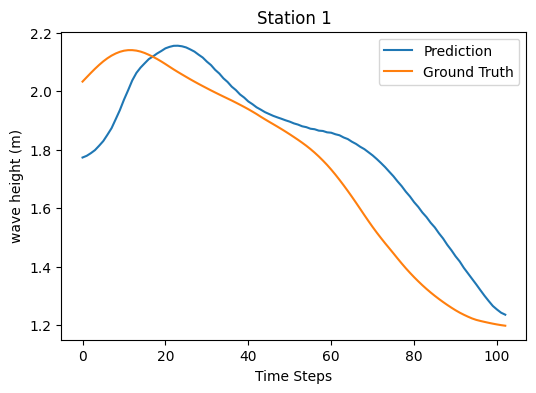

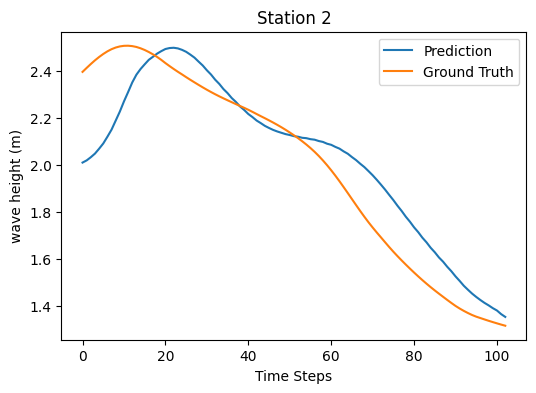

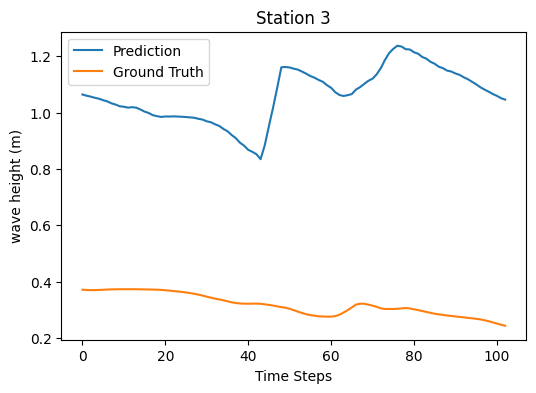

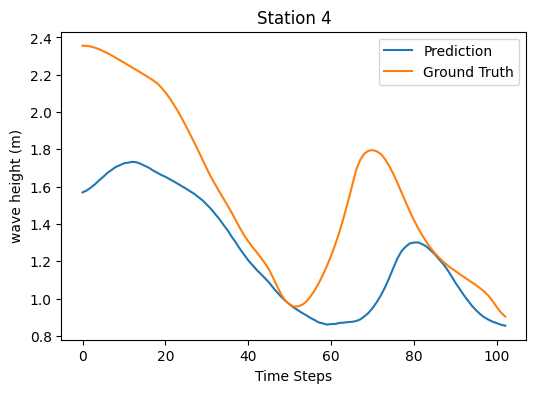

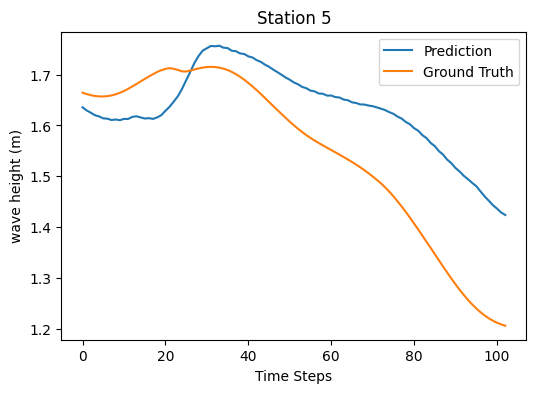

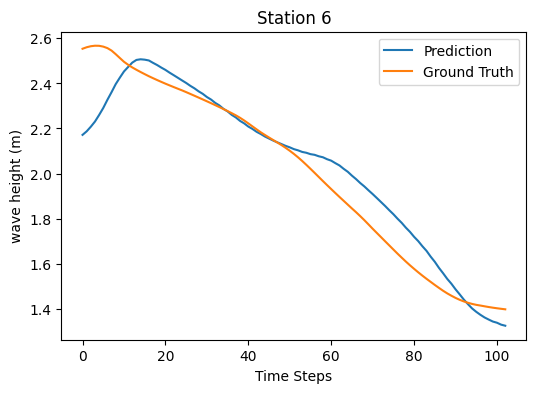

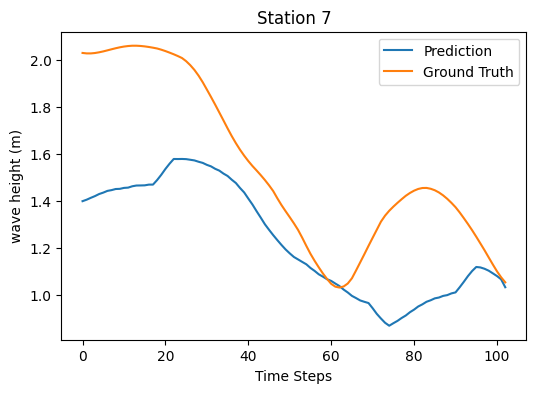

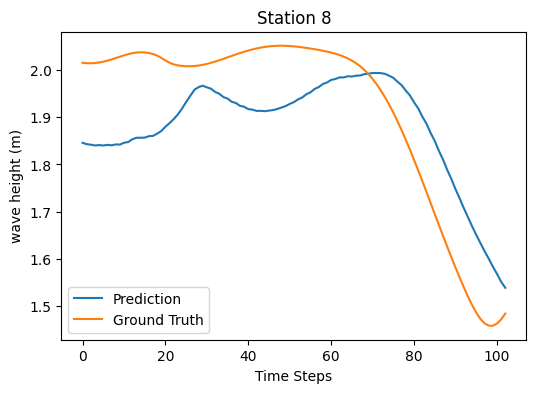

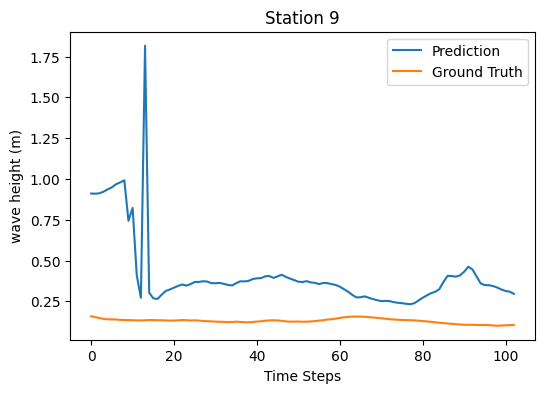

In [22]:
# Sample data
A = y_pred_save.shape[0]  # Number of time steps
B = y_pred_save.shape[1]    # Number of individual time-series gathering stations

pred_np = y_pred_save.numpy()
gt_np = y_test_cnn_flat.numpy()

# Create a time vector for the x-axis
time_steps = np.arange(A)

for station in range(B):
    plt.figure(figsize=(6, 4))
    plt.plot(time_steps, pred_np[:, station], label='Prediction')
    plt.plot(time_steps, gt_np[:, station], label='Ground Truth')
    plt.title(f'Station {station + 1}')
    plt.xlabel('Time Steps')
    plt.ylabel('wave height (m)')
    plt.legend()
    # plt.grid(True)
    plt.show()

## Geometric Neural Net
- Space only GNN using 2-layer GCN

In [23]:
from torch_geometric.data import Data

In [24]:
num_graphs = X_train.shape[0]
num_nodes = X_train.shape[1]
num_features = X_train.shape[2] * X_train.shape[3]

num_graphs, num_nodes, num_features

(256, 9, 72)

Creating graphs

In [25]:
edge_index = torch.combinations(torch.arange(num_nodes), r=2).t()
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

train_graphs = []
for i in range(num_graphs):
    node_features = X_train_flat[i]
    data = Data(x=node_features, edge_index=edge_index, y=y_train_flat[i])
    train_graphs.append(data)

test_graphs = []
for i in range(X_test.shape[0]):
    node_features = X_test_flat[i]
    data = Data(x=node_features, edge_index=edge_index, y=y_test_flat[i])
    test_graphs.append(data)
    
len(train_graphs), len(test_graphs)

(256, 103)

In [26]:
train_graphs[0]

Data(x=[9, 72], edge_index=[2, 72], y=[9])

In [27]:
# define GCN model
class SpaceGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(SpaceGNN, self).__init__()
        # self.conv1 = GCNConv(input_dim, hidden_dim)
        # self.conv2 = GCNConv(hidden_dim, output_dim)
        self.conv1 = GATv2Conv(input_dim, hidden_dim, heads=8, dropout=0.6)
        self.conv2 = GATv2Conv(hidden_dim * 8, output_dim, heads=1, concat=False, dropout=0.4)
        
        self.linear = nn.Linear(output_dim, 1)
    
    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        # x = nn.ReLU()(x)
        x = nn.LeakyReLU(negative_slope=0.2)(x)
        x = self.conv2(x, edge_index)
        # x = nn.ReLU()(x)
        # x = self.conv3(x, edge_index)
        # x = torch.relu(x)
        # x = self.linear(x)
        return x

In [31]:
time_mlp = TimeMLP(input_size=X_train_flat.shape[2], hidden_size=240, output_size=1)
space_gnn = SpaceGNN(input_dim=X_train_flat.shape[2], hidden_dim=80, output_dim=1)

In [32]:
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(space_gnn.parameters(), lr=0.001)
# scheduler = StepLR(optimizer, step_size=50, gamma=0.1)

space_gnn.train()

for epoch in range(epochs):
    space_gnn.train()

    optimizer.zero_grad()
    y_hat = None
    
    for i, data in enumerate(train_graphs):
        if y_hat is None:
            y_hat = space_gnn(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, space_gnn(data.x, data.edge_index)), dim=1)
        
    y_hat = y_hat.transpose(0,1)
    loss = criterion(y_hat, y_train_flat)
    
    loss.backward()
    optimizer.step()
    # scheduler.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 347.08477783203125
Epoch: 10, Loss: 115.47126007080078
Epoch: 20, Loss: 32.88705062866211
Epoch: 30, Loss: 10.980244636535645
Epoch: 40, Loss: 6.835174560546875
Epoch: 50, Loss: 5.299218654632568
Epoch: 60, Loss: 4.295083045959473
Epoch: 70, Loss: 3.206925392150879
Epoch: 80, Loss: 3.153531074523926
Epoch: 90, Loss: 2.8346052169799805


In [33]:
eval_criterion = nn.L1Loss()

space_gnn.eval()
with torch.no_grad():
    y_hat = None
    
    for i, data in enumerate(test_graphs):
        if y_hat is None:
            y_hat = space_gnn(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, space_gnn(data.x, data.edge_index)), dim=1)
    
    y_hat = y_hat.transpose(0,1)
    
    loss = eval_criterion(y_hat, y_test_flat)
    print(f'Loss: {loss.item()}')

Loss: 1.0519263744354248


In [34]:
class TimeThenSpace(nn.Module):
    def __init__(self, input_dim, time_hidden, time_out, space_hidden, output_dim):
        super(TimeThenSpace, self).__init__()
        
        self.time_nn = nn.Sequential(
            nn.Linear(input_dim, time_hidden * 2),
            nn.ReLU(),
            nn.Linear(time_hidden * 2, time_hidden),
            nn.ReLU(),
            nn.Linear(time_hidden, time_out)
        )
        # self.time_nn = nn.Linear(input_dim, time_out)
        
        self.space_nn = SpaceGNN(input_dim=time_out, hidden_dim=space_hidden, output_dim=output_dim)
        # self.space_nn = GCNConv(time_out, output_dim)
    
    def forward(self, x, edge_index):
        x = self.time_nn(x)
        x = self.space_nn(x, edge_index)
        return x

class SpaceThenTime(nn.Module):
    def __init__(self, input_dim, time_hidden, space_hidden, space_out, output_dim):
        super(SpaceThenTime, self).__init__()
        
        self.space_nn = SpaceGNN(input_dim=input_dim, hidden_dim=space_hidden, output_dim=space_out)
        
        self.time_nn = nn.Sequential(
            nn.Linear(space_out, time_hidden * 2),
            nn.ReLU(),
            nn.Linear(time_hidden * 2, time_hidden),
            nn.ReLU(),
            nn.Linear(time_hidden, 1)
        )
    
    def forward(self, x, edge_index):
        x = self.space_nn(x, edge_index)
        x = self.time_nn(x)
        return x

In [35]:
time_then_space = TimeThenSpace(input_dim=X_train_flat.shape[2], time_hidden=80, time_out=60, space_hidden=48, output_dim=1)
space_then_time = SpaceThenTime(input_dim=X_train_flat.shape[2], time_hidden=48, space_hidden=80, space_out=64, output_dim=1)

In [36]:
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_then_space.parameters(), lr=0.001)

time_then_space.train()

for epoch in range(epochs):
    time_then_space.train()

    optimizer.zero_grad()
    y_hat = None
    
    for i, data in enumerate(train_graphs):
        if y_hat is None:
            y_hat = time_then_space(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, time_then_space(data.x, data.edge_index)), dim=1)
    
    y_hat = y_hat.transpose(0,1)
    loss = criterion(y_hat, y_train_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 6.844514846801758
Epoch: 10, Loss: 2.719083070755005
Epoch: 20, Loss: 2.500657558441162
Epoch: 30, Loss: 2.3242452144622803
Epoch: 40, Loss: 2.3993287086486816
Epoch: 50, Loss: 2.317049264907837
Epoch: 60, Loss: 2.2752935886383057
Epoch: 70, Loss: 1.9423497915267944
Epoch: 80, Loss: 1.541741967201233
Epoch: 90, Loss: 1.3325021266937256


In [37]:
eval_criterion = nn.L1Loss()

time_then_space.eval()
with torch.no_grad():
    y_hat = None
    
    for i, data in enumerate(test_graphs):
        if y_hat is None:
            y_hat = time_then_space(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, time_then_space(data.x, data.edge_index)), dim=1)
    
    y_hat = y_hat.transpose(0,1)
    loss = eval_criterion(y_hat, y_test_flat)
    print(f'Loss: {loss.item()}')

Loss: 0.5386671423912048


In [108]:
epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(space_then_time.parameters(), lr=0.001)

space_then_time.train()

for epoch in range(epochs):
    space_then_time.train()

    optimizer.zero_grad()
    y_hat = None
    
    for i, data in enumerate(train_graphs):
        if y_hat is None:
            y_hat = space_then_time(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, space_then_time(data.x, data.edge_index)), dim=1)
    
    y_hat = y_hat.transpose(0,1)
    loss = criterion(y_hat, y_train_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 8.161552429199219
Epoch: 10, Loss: 5.5516767501831055
Epoch: 20, Loss: 5.10250997543335
Epoch: 30, Loss: 4.819548606872559
Epoch: 40, Loss: 4.395674228668213
Epoch: 50, Loss: 4.5356597900390625
Epoch: 60, Loss: 4.35856819152832
Epoch: 70, Loss: 4.050288677215576
Epoch: 80, Loss: 4.14106559753418
Epoch: 90, Loss: 3.66304612159729


In [109]:
eval_criterion = nn.L1Loss()

space_then_time.eval()
with torch.no_grad():
    y_hat = None
    
    for i, data in enumerate(test_graphs):
        if y_hat is None:
            y_hat = space_then_time(data.x, data.edge_index)
        else:
            y_hat = torch.cat((y_hat, space_then_time(data.x, data.edge_index)), dim=1)
    
    y_hat = y_hat.transpose(0,1)
    loss = eval_criterion(y_hat, y_test_flat)
    print(f'Loss: {loss.item()}')

Loss: 0.8079506754875183


## Manual Aggregation for Time only Neural Net
- to test whether combining data from multiple stations is useful for this task/region/data (i.e. is spatial component useful)
- test the homophily by running a time-only network but combining all features from all stations at each time step (manual aggregation of all station info for each timestep) -- data shape (N, O * F * W) and output shape (N, O)
- **confirmed that for the Irish coast dataset at least, *naive inclusion of nearby buoy data is not useful and can harm performance***

In [91]:
X_train_mg = X_train.reshape(X_train.shape[0], X_train.shape[1] * X_train.shape[3] * X_train.shape[2])
X_test_mg = X_test.reshape(X_test.shape[0], X_test.shape[1] * X_test.shape[3] * X_test.shape[2])

X_train_mg.shape, X_test_mg.shape

(torch.Size([256, 648]), torch.Size([103, 648]))

In [92]:
mlp_mg = TimeMLP(input_size=X_train_mg.shape[1], hidden_size=320, output_size=9)

epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_mg.parameters(), lr=0.001)

mlp_mg.train()

for epoch in range(epochs):
    mlp_mg.train()

    optimizer.zero_grad()
    
    y_hat = mlp_mg(X_train_mg)
    
    loss = criterion(y_hat.squeeze(), y_train)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

Epoch: 0, Loss: 66.71395111083984
Epoch: 10, Loss: 3.142827033996582
Epoch: 20, Loss: 0.9603611826896667
Epoch: 30, Loss: 0.23523157835006714
Epoch: 40, Loss: 0.13935403525829315
Epoch: 50, Loss: 0.1178605929017067
Epoch: 60, Loss: 0.07885698229074478
Epoch: 70, Loss: 0.07040433585643768
Epoch: 80, Loss: 0.062250714749097824
Epoch: 90, Loss: 0.057209987193346024


In [93]:
eval_criterion = nn.L1Loss()

mlp_mg.eval()
with torch.no_grad():
    y_pred = mlp_mg(X_test_mg)
    
    loss = eval_criterion(y_pred, y_test)
    print(f'Loss: {loss.item()}')

Loss: 0.5546430945396423


### Batch testing
experiment with the batching capabilities in PyG for efficient ST graph processing

In [38]:
from torch_geometric.data import Batch

In [39]:
train_batch = Batch.from_data_list(train_graphs)
test_batch = Batch.from_data_list(test_graphs)

In [46]:
time_then_space = TimeThenSpace(input_dim=X_train_flat.shape[2], time_hidden=80, time_out=60, space_hidden=48, output_dim=1)

epochs = 100
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(time_then_space.parameters(), lr=0.001)

time_then_space.train()

for epoch in range(epochs):
    time_then_space.train()

    optimizer.zero_grad()
    
    y_hat = time_then_space(train_batch.x, train_batch.edge_index)
    y_hat = y_hat.reshape(y_train_flat.shape[0], y_train_flat.shape[1])
    
    loss = criterion(y_hat, y_train_flat)
    
    loss.backward()
    optimizer.step()
    
    if epoch % (epochs // 10) == 0:
        print(f'Epoch: {epoch}, Loss: {loss.item()}')

eval_criterion = nn.L1Loss()

time_then_space.eval()
with torch.no_grad():
    y_hat = time_then_space(test_batch.x, test_batch.edge_index)
    y_hat = y_hat.reshape(y_test_flat.shape[0], y_test_flat.shape[1])
    
    loss = eval_criterion(y_hat, y_test_flat)
    print(f'Loss: {loss.item()}')

Epoch: 0, Loss: 4.820329666137695
Epoch: 10, Loss: 5.113584995269775
Epoch: 20, Loss: 2.6959829330444336
Epoch: 30, Loss: 2.522704601287842
Epoch: 40, Loss: 2.4844257831573486
Epoch: 50, Loss: 2.4898478984832764
Epoch: 60, Loss: 2.451786994934082
Epoch: 70, Loss: 2.289787769317627
Epoch: 80, Loss: 2.3398241996765137
Epoch: 90, Loss: 2.331702947616577
Loss: 0.5855336785316467
